Importing Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

Generating Dataset

In [2]:
np.random.seed(42)

def true_function(x):
    return np.sin(1.5 * np.pi * x)

n_samples = 200

X = np.sort(np.random.rand(n_samples))
y = true_function(X) + np.random.normal(0, 0.25, n_samples)

X = X.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

Training Samples : 140
Testing Samples  : 60


Visualizing Dataset

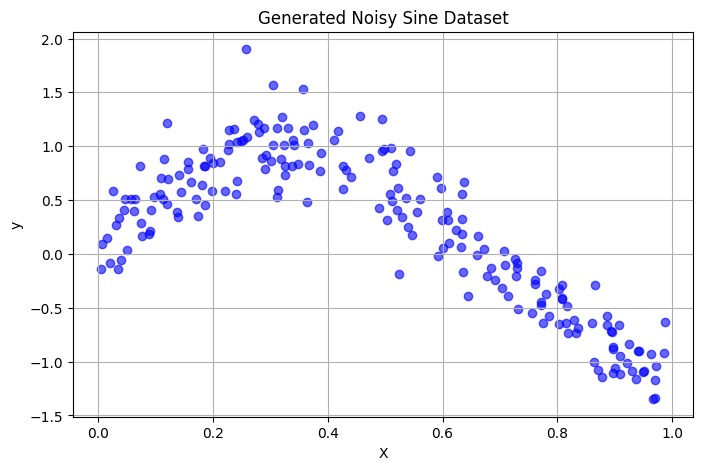

In [3]:
plt.figure(figsize=(8,5))

plt.scatter(X, y, color='blue', alpha=0.6)

plt.title("Generated Noisy Sine Dataset")
plt.xlabel("X")
plt.ylabel("y")

plt.grid(True)

plt.show()

**Part A (Question 1 & 2)**

Training Fully Grown Decision Tree

In [4]:
dt = DecisionTreeRegressor(
    max_depth=None,
    random_state=42
)

dt.fit(X_train, y_train)

train_pred = dt.predict(X_train)
test_pred = dt.predict(X_test)

train_mse = mean_squared_error(y_train, train_pred)
test_mse = mean_squared_error(y_test, test_pred)

print("Decision Tree (Fully Grown)")
print("-"*40)

print(f"Train MSE : {train_mse:.4f}")
print(f"Test MSE  : {test_mse:.4f}")

Decision Tree (Fully Grown)
----------------------------------------
Train MSE : 0.0000
Test MSE  : 0.1205


**Part A (Question 3)**

Different Depths

In [5]:
depths = [1, 2, 3, 5, 8, 12, None]

train_errors = []
test_errors = []

for depth in depths:

    model = DecisionTreeRegressor(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_prediction = model.predict(X_train)
    test_prediction = model.predict(X_test)

    train_errors.append(
        mean_squared_error(y_train, train_prediction)
    )

    test_errors.append(
        mean_squared_error(y_test, test_prediction)
    )

**Plotting Train/Test MSE vs Max Depth**

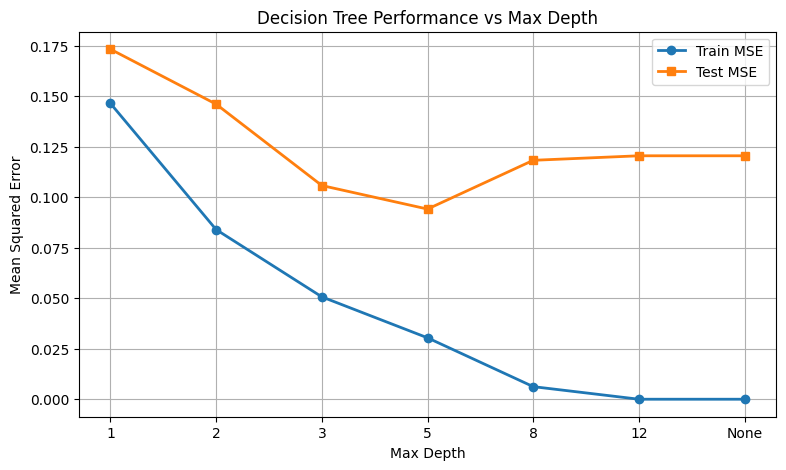

In [6]:
depth_labels = ["1","2","3","5","8","12","None"]

plt.figure(figsize=(9,5))

plt.plot(
    depth_labels,
    train_errors,
    marker='o',
    linewidth=2,
    label="Train MSE"
)

plt.plot(
    depth_labels,
    test_errors,
    marker='s',
    linewidth=2,
    label="Test MSE"
)

plt.title("Decision Tree Performance vs Max Depth")

plt.xlabel("Max Depth")
plt.ylabel("Mean Squared Error")

plt.legend()

plt.grid(True)

plt.show()

**Question 4**

At max_depth = 1, the model has high bias and low variance.

A depth of 1 creates a very simple tree with only one split. Since the model is too simple to capture the nonlinear sine relationship, it underfits the data. As a result, both training and testing errors remain relatively high.

**Question 5**

When max_depth = None, the tree grows until every possible split is made.

The training MSE becomes extremely low because the model memorizes the training data. However, the testing MSE increases because the model also learns the noise in the dataset. This behavior indicates overfitting and high variance.

**Part B (Question 6 & 7)**

In [7]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

rf.fit(X_train, y_train)

rf_train = rf.predict(X_train)
rf_test = rf.predict(X_test)

rf_train_mse = mean_squared_error(y_train, rf_train)
rf_test_mse = mean_squared_error(y_test, rf_test)

print("Random Forest Results")
print("-"*40)

print(f"Train MSE : {rf_train_mse:.4f}")
print(f"Test MSE  : {rf_test_mse:.4f}")

print()

print("Comparison")

print(f"Decision Tree Test MSE : {test_mse:.4f}")
print(f"Random Forest Test MSE : {rf_test_mse:.4f}")

Random Forest Results
----------------------------------------
Train MSE : 0.0105
Test MSE  : 0.1012

Comparison
Decision Tree Test MSE : 0.1205
Random Forest Test MSE : 0.1012


**Question 8**

In [8]:
estimators = [1,5,10,20,50,100,200]

rf_train_errors = []
rf_test_errors = []

for n in estimators:

    model = RandomForestRegressor(
        n_estimators=n,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_prediction = model.predict(X_train)
    test_prediction = model.predict(X_test)

    rf_train_errors.append(
        mean_squared_error(y_train, train_prediction)
    )

    rf_test_errors.append(
        mean_squared_error(y_test, test_prediction)
    )

Plot Random Forest Performance

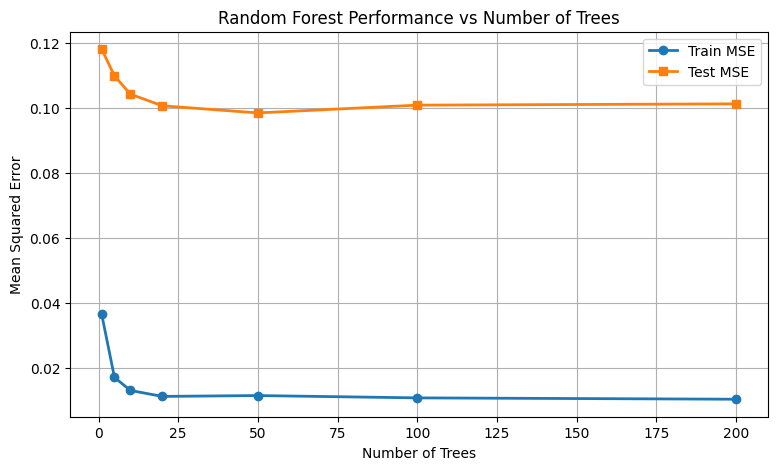

In [9]:
plt.figure(figsize=(9,5))

plt.plot(
    estimators,
    rf_train_errors,
    marker='o',
    linewidth=2,
    label="Train MSE"
)

plt.plot(
    estimators,
    rf_test_errors,
    marker='s',
    linewidth=2,
    label="Test MSE"
)

plt.title("Random Forest Performance vs Number of Trees")

plt.xlabel("Number of Trees")
plt.ylabel("Mean Squared Error")

plt.legend()

plt.grid(True)

plt.show()

**Question 9**

As the number of trees increases, the Random Forest averages the predictions of many decision trees. This averaging reduces variance, resulting in lower testing error.

The training MSE remains nearly constant because each individual tree is already well fitted to the training data.

**Question 10**

Adding more trees generally does not cause Random Forest to overfit more.

Each tree makes slightly different predictions because it is trained on a different bootstrap sample and uses random feature selection. Averaging these predictions reduces variance and produces a more stable model. Therefore, increasing the number of trees usually improves or stabilizes performance instead of increasing overfitting.

**Part C (Question 11)**

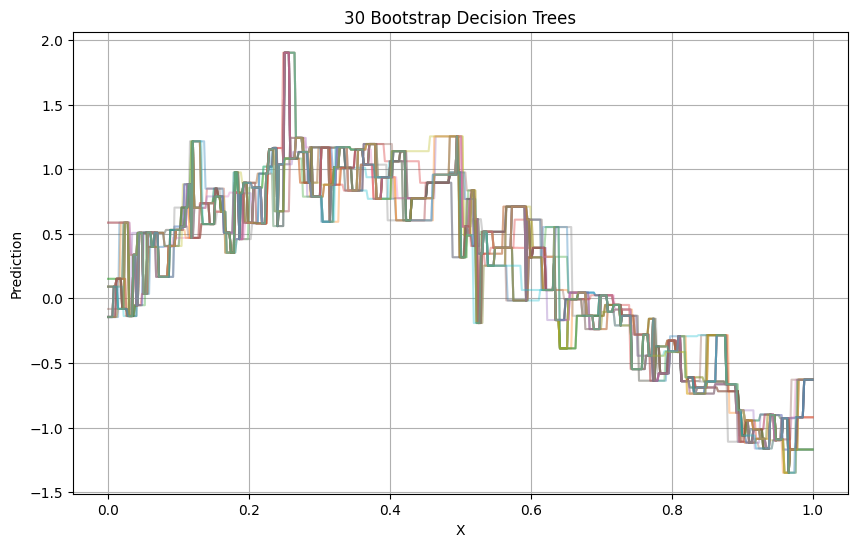

In [10]:
x_plot = np.linspace(0, 1, 500).reshape(-1,1)

plt.figure(figsize=(10,6))

for i in range(30):

    indices = np.random.choice(
        len(X_train),
        len(X_train),
        replace=True
    )

    X_boot = X_train[indices]
    y_boot = y_train[indices]

    tree = DecisionTreeRegressor(random_state=i)

    tree.fit(X_boot, y_boot)

    prediction = tree.predict(x_plot)

    plt.plot(
        x_plot,
        prediction,
        alpha=0.35
    )

plt.title("30 Bootstrap Decision Trees")

plt.xlabel("X")
plt.ylabel("Prediction")

plt.grid(True)

plt.show()

**Question 12**

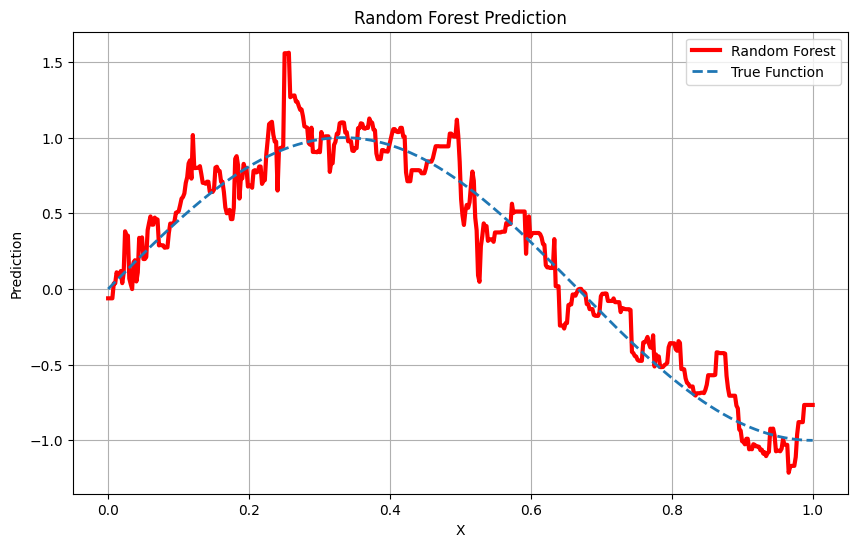

In [11]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_prediction = rf.predict(x_plot)

plt.figure(figsize=(10,6))

plt.plot(
    x_plot,
    rf_prediction,
    color="red",
    linewidth=3,
    label="Random Forest"
)

plt.plot(
    x_plot,
    true_function(x_plot),
    linestyle="--",
    linewidth=2,
    label="True Function"
)

plt.legend()

plt.title("Random Forest Prediction")

plt.xlabel("X")
plt.ylabel("Prediction")

plt.grid(True)

plt.show()

**Question 13**

The overlay of 30 Decision Trees shows much greater spread, indicating high variance. Each tree makes different predictions because it is trained on a different bootstrap sample.

The Random Forest prediction is much smoother and stays closer to the true sine function. This indicates lower variance while maintaining a similar level of bias.

**Question 14**

Random Forest reduces variance by combining the predictions of many Decision Trees trained on different bootstrap samples. This technique is called bagging (Bootstrap Aggregating). Since the individual trees make different errors, averaging their predictions cancels out many of these errors. As a result, the Random Forest produces more stable and accurate predictions than a single Decision Tree while keeping bias nearly unchanged.